In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 1. CHARGEMENT DES DONNÉES
df = pd.read_csv('../data/clean_data.csv', encoding='ISO-8859-1')

In [4]:

#  CRÉER LA COLONNE REVENUE
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(df.columns.tolist())
print(f" Revenue créée ! Exemple : {df['Revenue'].head(3).tolist()}")


['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'CA', 'Mois', 'Jour', 'Heure', 'Revenue']
 Revenue créée ! Exemple : [15.299999999999999, 20.34, 22.0]


In [5]:
# KPI : MARKETING 

# Revenu total par pays
revenu_pays = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

# Top 10 pays
top10_pays = revenu_pays.head(10)

print(" TOP 10 PAYS PAR REVENU")
for i, (pays, rev) in enumerate(top10_pays.items(), 1):
    print(f"{i}. {pays}: £{rev:,.0f}")

# Part du UK vs reste du monde
uk_revenue = revenu_pays.get('United Kingdom', 0)
total_revenue = revenu_pays.sum()
autres_revenue = total_revenue - uk_revenue

print(f"\n RÉPARTITION :")
print(f"🇬🇧 UK : £{uk_revenue:,.0f} ({uk_revenue/total_revenue*100:.1f}%)")
print(f" Autres : £{autres_revenue:,.0f} ({autres_revenue/total_revenue*100:.1f}%)")


 TOP 10 PAYS PAR REVENU
1. United Kingdom: £7,285,025
2. Netherlands: £285,446
3. EIRE: £265,262
4. Germany: £228,678
5. France: £208,934
6. Australia: £138,454
7. Spain: £61,559
8. Switzerland: £56,444
9. Belgium: £41,196
10. Sweden: £38,368

 RÉPARTITION :
🇬🇧 UK : £7,285,025 (82.0%)
 Autres : £1,602,184 (18.0%)


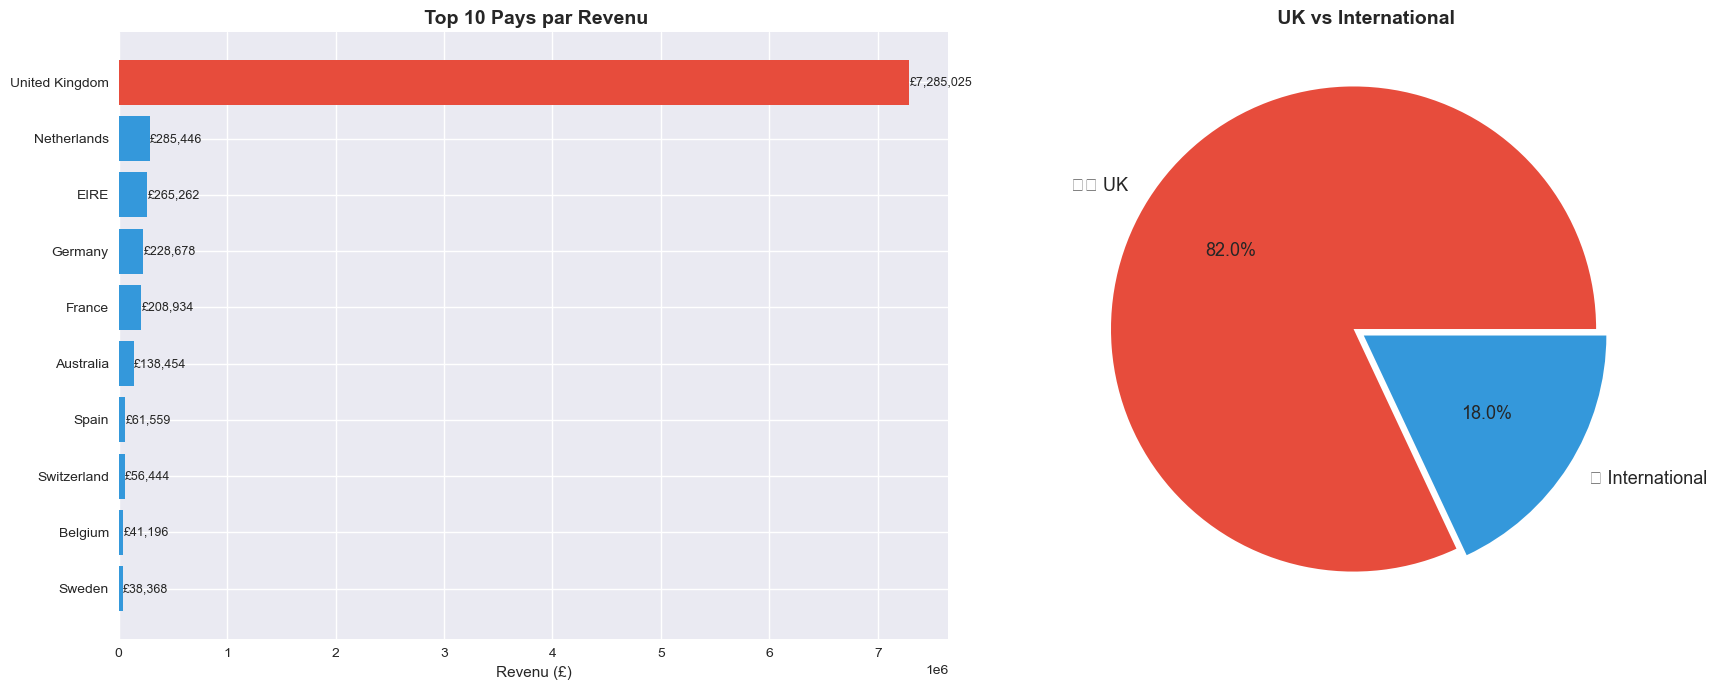

In [9]:
#  GRAPHIQUE TOP 10 PAYS

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart Top 10
colors = ['#e74c3c' if p == 'United Kingdom' else '#3498db' for p in top10_pays.index]
axes[0].barh(top10_pays.index[::-1], top10_pays.values[::-1], color=colors[::-1])
axes[0].set_title(' Top 10 Pays par Revenu', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Revenu (£)')

for i, v in enumerate(top10_pays.values[::-1]):
    axes[0].text(v + 5000, i, f'£{v:,.0f}', va='center', fontsize=9)

# Pie chart UK vs Monde
axes[1].pie([uk_revenue, autres_revenue], 
            labels=['🇬🇧 UK', '🌍 International'],
            autopct='%1.1f%%', 
            colors=['#e74c3c', '#3498db'],
            explode=(0.05, 0),
            textprops={'fontsize': 13})
axes[1].set_title(' UK vs International', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
